In [6]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# loading the datasets
df_suicide_rates = pd.read_csv("master.csv")
df_gdp_per_capita_growth = pd.read_csv("gdp_per_capita_growth.csv")

In [8]:
pd.set_option("display.max_columns", None)
df_suicide_rates.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [9]:
df_gdp_per_capita_growth.head()

,Country Name,Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.593281,20.136808,12.201491,2.089655,3.834679,0.270154,1.009406,2.265067,-2.073120,-2.324846,4.241983,-0.146480,-0.728507,5.417262,-5.087480,-5.411988,-0.151921,6.023133,-0.084879,0.246853,1.401980,-0.224759,-10.599128,-3.886820,3.055788,-1.865105,3.592223,-0.290534,5.129657,1.587869,1.519821,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012356,-2.561362,-2.705186,0.351861,-3.073432,-0.762183,0.908317,1.167326,-0.299012,-2.781214,-2.883706,-5.032680,-3.775331,-0.680731,1.654705,2.820756,0.762306,-0.810512,-0.008863,0.569978,0.888640,1.337972,0.271501,2.933164,3.599817,3.898307,4.044778,1.803462,-1.740180,2.340620,1.223828,-0.769509,1.505305,1.203260,0.187860,-0.674533,-0.144710,-0.185406,-0.544414,-5.403820,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.868380,-2.875203,7.207967,2.253311,11.022787,1.594215,18.515419,11.264091,-2.681061,8.974865,1.974166,-0.665291,-1.622857,-0.541416,0.064764,-1.194900,1.535637,-4.575032,NaN
3,Africa Western and Central,AFW,NaN,-0.232405,1.602299,4.990675,3.12468,1.783947,-3.946431,-11.557321,-0.819528,12.849537,15.163648,8.185152,0.666409,1.662969,7.496019,-4.660261,5.752187,1.95334,-4.815705,2.39104,-0.764812,-9.454446,-5.971491,-9.068330,-2.164209,2.698023,-1.321700,-1.281859,2.034221,-0.453005,3.742241,-1.536811,0.010263,-3.736008,-2.899441,-0.738984,1.880986,1.487565,0.773380,-1.256301,1.000027,2.444935,7.010741,2.738269,5.149780,3.018704,2.533622,2.667866,3.386357,3.383289,4.056566,2.017199,2.315175,3.260886,3.096784,0.007402,-2.533562,-0.390665,0.241531,0.492953,-3.453976,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.710278,-3.490383,0.548516,2.288508,-0.107615,-0.670778,0.488467,2.496630,-3.335954,-6.657467,-2.310868,-8.876931,-26.411771,-1.877898,11.359539,9.952787,3.877858,1.364744,-1.085298,-0.267956,0.822138,9.943758,-0.431834,7.187064,11.030783,7.582319,9.890049,7.116848,-2.808600,0.640263,-0.220843,4.706519,1.291994,1.219881,-2.468737,-5.816188,-3.409983,-5.162112,-3.795608,-8.396241,NaN


In [10]:
df_suicide_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


#### Conclusion

We will need to preprocess the data before we start to our data analysis

In [11]:
# clean column names in df_suicide_rates
# renaming specific columns to make them more pythonic and easier to query
df_suicide_rates.rename(columns={
    " gdp_for_year ($) ": "gdp_for_year",
    "gdp_per_capita ($)": "gdp_per_capita",
    "suicides/100k pop": "suicides_per_100k"
}, inplace = True)

In [12]:
# convert "gdp_for_year" column from string to integer format
df_suicide_rates["gdp_for_year"] = df_suicide_rates["gdp_for_year"].str.replace(",","").astype(int)

In [13]:
# drop the redundant "country-year" column
# drop the "HDI for year" column due to the 60% missing data
df_suicide_rates.drop("country-year", axis=1, inplace = True)
df_suicide_rates.drop("HDI for year", axis=1, inplace = True)

In [14]:
# reshape the gdp growth dataset to merge 2 datasets
df_growth_long = pd.melt(
    df_gdp_per_capita_growth,
    id_vars = ["Country Name", "Code"],
    var_name = "year",
    value_name = "gdp_growth_rate"
)

In [15]:
df_growth_long["year"].unique()

array(['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967',
       '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975',
       '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', 'Unnamed: 65'],
      dtype=object)

In [16]:
# clean the "year" column in df_growth_long
df_growth_long["year"] = pd.to_numeric(df_growth_long["year"], errors = "coerce")
df_growth_long.dropna(subset = ["year"], inplace = True)
df_growth_long["year"] = df_growth_long["year"].astype(int)

In [17]:
df_growth_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16226 entries, 0 to 16225
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country Name     16226 non-null  object 
 1   Code             16226 non-null  object 
 2   year             16226 non-null  int64  
 3   gdp_growth_rate  12150 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 633.8+ KB


In [18]:
# merge the two datasets
final_df = pd.merge(
    df_suicide_rates,
    df_growth_long.drop(columns = ["Code"]),
    left_on = ["country", "year"],
    right_on = ["Country Name", "year"],
    how = "left"
)

In [19]:
final_df.head()

,country,year,sex,age,suicides_no,population,suicides_per_100k,gdp_for_year,gdp_per_capita,generation,Country Name,gdp_growth_rate
0,Albania,1987,male,15-24 years,21,312900,6.71,2156624900,796,Generation X,Albania,-2.749496
1,Albania,1987,male,35-54 years,16,308000,5.19,2156624900,796,Silent,Albania,-2.749496
2,Albania,1987,female,15-24 years,14,289700,4.83,2156624900,796,Generation X,Albania,-2.749496
3,Albania,1987,male,75+ years,1,21800,4.59,2156624900,796,G.I. Generation,Albania,-2.749496
4,Albania,1987,male,25-34 years,9,274300,3.28,2156624900,796,Boomers,Albania,-2.749496


In [20]:
final_df.drop("Country Name", axis = 1, inplace = True)

In [21]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            27820 non-null  object 
 1   year               27820 non-null  int64  
 2   sex                27820 non-null  object 
 3   age                27820 non-null  object 
 4   suicides_no        27820 non-null  int64  
 5   population         27820 non-null  int64  
 6   suicides_per_100k  27820 non-null  float64
 7   gdp_for_year       27820 non-null  int64  
 8   gdp_per_capita     27820 non-null  int64  
 9   generation         27820 non-null  object 
 10  gdp_growth_rate    25204 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 2.3+ MB


In [22]:
# check the values of original suicide rates df's country column to compare it with null gdp_growth_rate countries
final_df[final_df["gdp_growth_rate"].isnull()].groupby("country").size()

country
Armenia                          12
Azerbaijan                       12
Bahamas                         276
Belarus                          12
Canada                          156
Croatia                          12
Czech Republic                   12
Estonia                          12
Hungary                          12
Iceland                         132
Israel                          132
Kazakhstan                       12
Kuwait                           72
Kyrgyzstan                      312
Latvia                           12
Lithuania                        12
Macau                            12
Poland                           12
Qatar                            12
Republic of Korea               372
Romania                          24
Russian Federation               12
Saint Kitts and Nevis            36
Saint Lucia                     336
Saint Vincent and Grenadines    300
Slovakia                        264
Slovenia                         12
Turkmenistan        

#### Conclusion

12 rows of missing data means that one year of data is missing, so we can assume that there is no problem about country names match between our two datasets. But we need to solve the problem with the other countries.

In [23]:
# country name fix

country_mapping = {
    'Slovak Republic': 'Slovakia',
    'Macao SAR, China': 'Macau',
    'St. Kitts and Nevis': 'Saint Kitts and Nevis',
    'St. Vincent and the Grenadines': 'Saint Vincent and Grenadines',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Korea, Rep.': 'Republic of Korea',
    'Bahamas, The': 'Bahamas',
    'St. Lucia': 'Saint Lucia'
}

df_growth_long["Country Name"] = df_growth_long["Country Name"].replace(country_mapping)

In [24]:
# let's merge the two datasets again and check if we've fixed the country name mismatch issue.
final_df = pd.merge(
    df_suicide_rates,
    df_growth_long[["Country Name", "year", "gdp_growth_rate"]],
    left_on = ["country", "year"],
    right_on = ["Country Name", "year"],
    how = "left"
)

final_df.drop(columns = ["Country Name"], inplace = True)

final_df[final_df["gdp_growth_rate"].isnull()].groupby("country").size()

country
Armenia                12
Azerbaijan             12
Belarus                12
Canada                156
Croatia                12
Czech Republic         12
Estonia                12
Hungary                12
Iceland               132
Israel                132
Kazakhstan             12
Kuwait                 72
Latvia                 12
Lithuania              12
Poland                 12
Qatar                  12
Romania                24
Russian Federation     12
Slovakia               12
Slovenia               12
Turkmenistan           12
Ukraine                12
dtype: int64

In [25]:
# try to understand why there is so much missing data on some countries' rows
missing_data_countries = ["Canada", "Iceland", "Israel", "Kuwait"]
for country in missing_data_countries:
    missing_years = final_df[(final_df["country"] == country) & (final_df["gdp_growth_rate"].isnull())]["year"].unique()
    print(f"{country} missing years: {missing_years}")

Canada missing years: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997]
Iceland missing years: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995]
Israel missing years: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995]
Kuwait missing years: [1985 1986 1987 1993 1994 1995]


In [26]:
# fill the missing values with the "linear interpolation" 
final_df.sort_values(by = ["country", "year"], inplace = True)

final_df["gdp_growth_rate"] = final_df.groupby("country")["gdp_growth_rate"].transform(
    lambda group: group.interpolate(method = "linear", limit_direction = "both"))

# let's check the results after interpolation
print(f"Missing data count on GDP Growth Rate Column: {final_df["gdp_growth_rate"].isnull().sum()} \n")

# let's check if we've filled the null data correctly
canada_sample = final_df[(final_df["country"] == "Canada")]

print(canada_sample[["country", "year", "gdp_growth_rate"]].drop_duplicates())

Missing data count on GDP Growth Rate Column: 0 

     country  year  gdp_growth_rate
4916  Canada  1985         1.946955
4928  Canada  1986         1.946955
4940  Canada  1987         1.946955
4952  Canada  1988         1.946955
4964  Canada  1989         1.946955
4976  Canada  1990         1.946955
4988  Canada  1991         1.946955
5000  Canada  1992         1.946955
5012  Canada  1993         1.946955
5024  Canada  1994         1.946955
5036  Canada  1995         1.946955
5048  Canada  1996         1.946955
5060  Canada  1997         1.946955
5072  Canada  1998         1.946955
5084  Canada  1999         3.128792
5096  Canada  2000         3.945219
5108  Canada  2001         0.309870
5120  Canada  2002         2.303577
5132  Canada  2003         2.879570
5144  Canada  2004         2.948998
5156  Canada  2005         4.008878
5168  Canada  2006         3.118693
5180  Canada  2007         5.835793
5192  Canada  2008        -0.080295
5204  Canada  2009        -4.030420
5216  Canada  

#### Conclusion
This does not look good. Our linear interpolation failed because some countries, such as Canada, lack information until a certain year. Our function tries to fill empty rows between two specific values, but fails because there is no starting point for the method.

#### Solution
I initially wanted to add this GDP growth rate data because it is real-world data adjusted for inflation. However, this approach increased complexity too much. I'll revert to "Occam's Razor" to reduce complexity and derive this metric directly from our main dataset.

In [27]:
# let's try to fill those empty data points using the gdp_per_capita column from our main dataset.
gdp_trend = final_df[["country", "year", "gdp_per_capita"]].drop_duplicates().sort_values(["country", "year"])
gdp_trend["calculated_gdp_growth"] = gdp_trend.groupby("country")["gdp_per_capita"].pct_change() * 100

final_df = pd.merge(final_df, gdp_trend[["country", "year", "calculated_gdp_growth"]], on = ["country", "year"], how = "left")


In [28]:
# since there is no previous year to compare, the calculated_gdp_growth column for the year 1985 is null for the entire dataset,
# therefore we can set these values to 0. But I want to check before filling all the null data points with 0.

# first year of all countries
first_years_of_countries = final_df.groupby("country")["year"].transform("min")
# see the data points that are null but also not the first year of a country.
problematic_nulls = final_df[
    (final_df["calculated_gdp_growth"].isnull()) &
    (final_df["year"] != first_years_of_countries)
]

print(f"Number of Empty Data Points Erroreously: {len(problematic_nulls)}")

Number of Empty Data Points Erroreously: 0


In [29]:
# fill the empty datapoints with 0.
final_df["calculated_gdp_growth"] = final_df["calculated_gdp_growth"].fillna(0)

print("Missing value count: ", final_df["calculated_gdp_growth"].isnull().sum())

Missing value count:  0


In [30]:
final_df.head()

,country,year,sex,age,suicides_no,population,suicides_per_100k,gdp_for_year,gdp_per_capita,generation,gdp_growth_rate,calculated_gdp_growth
0,Albania,1987,male,15-24 years,21,312900,6.71,2156624900,796,Generation X,-2.749496,0.0
1,Albania,1987,male,35-54 years,16,308000,5.19,2156624900,796,Silent,-2.749496,0.0
2,Albania,1987,female,15-24 years,14,289700,4.83,2156624900,796,Generation X,-2.749496,0.0
3,Albania,1987,male,75+ years,1,21800,4.59,2156624900,796,G.I. Generation,-2.749496,0.0
4,Albania,1987,male,25-34 years,9,274300,3.28,2156624900,796,Boomers,-2.749496,0.0


## Exploratory Data Analysis

#### Global Analysis

In [31]:
# since there is no continent column, we use country_converter lib to add it
!pip install country_converter

In [32]:
#import
import country_converter as coco

In [34]:
# add the country column to the dataframe
cc = coco.CountryConverter()
final_df["continent"] = cc.convert(names = final_df["country"].tolist(), to = "continent")

In [35]:
# graphic settings
sns.set_theme(style = "whitegrid", palette = "muted")

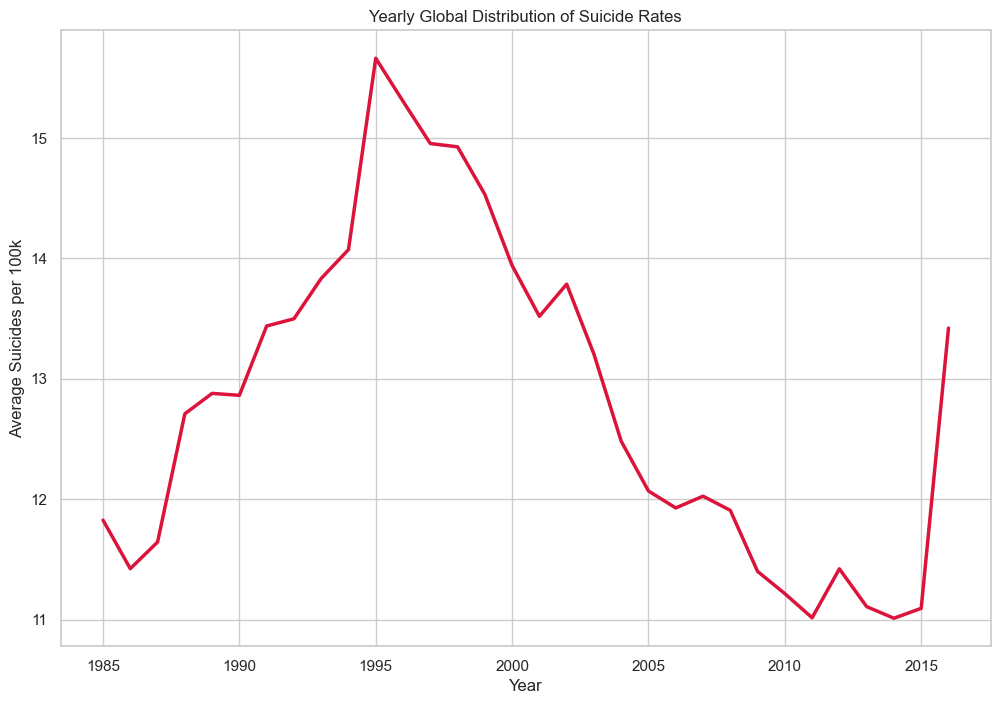

In [52]:
#suicide rates distribution by year
plt.figure(figsize = (12,8))
sns.lineplot(final_df, x = "year", y = "suicides_per_100k",errorbar = None, color = "crimson", linewidth = 2.5)
plt.title("Yearly Global Distribution of Suicide Rates")
plt.xlabel("Year")
plt.ylabel("Average Suicides per 100k")
plt.show()

#### Insight
Suicide incidances were peaked at 1995 around the globe for some unknown reason.

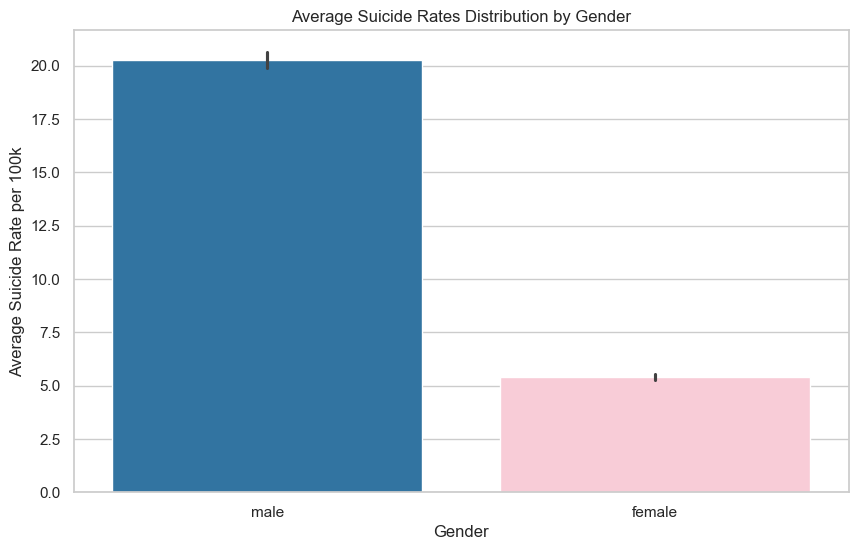

In [50]:
#suicide rates distribution by gender
plt.figure(figsize = (10,6))
sns.barplot(final_df, x = "sex", y = "suicides_per_100k", palette=['#1f77b4', '#FFC5D3'], hue = "sex")
plt.title("Average Suicide Rates Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Suicide Rate per 100k")
plt.show()

#### Insight
It looks like males are more suicidal than females

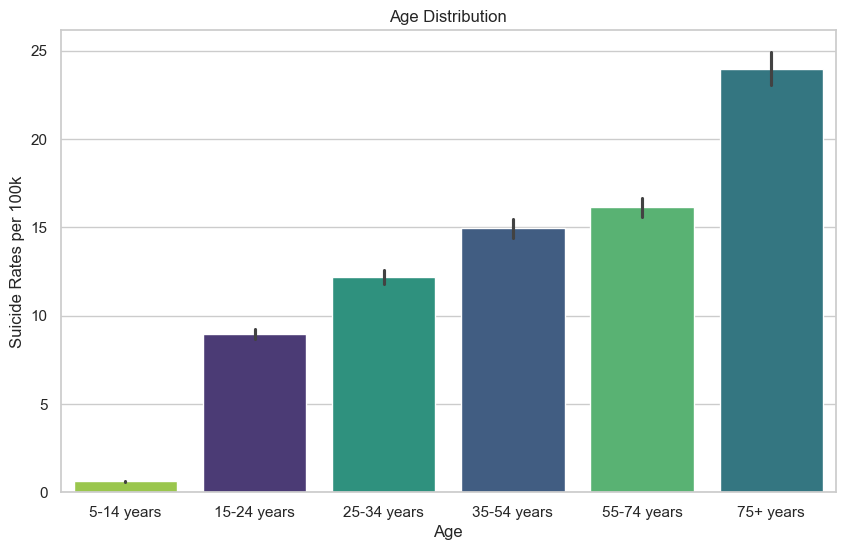

In [56]:
# suicide rates distribution by age
age_order = ['5-14 years', '15-24 years', '25-34 years', '35-54 years', '55-74 years', '75+ years']
plt.figure(figsize = (10,6))
sns.barplot(final_df, x = "age", y = "suicides_per_100k", order = age_order, palette = "viridis", hue = "age")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Suicide Rates per 100k")
plt.show()

#### Insight
It looks like people get more suicidal as they age.

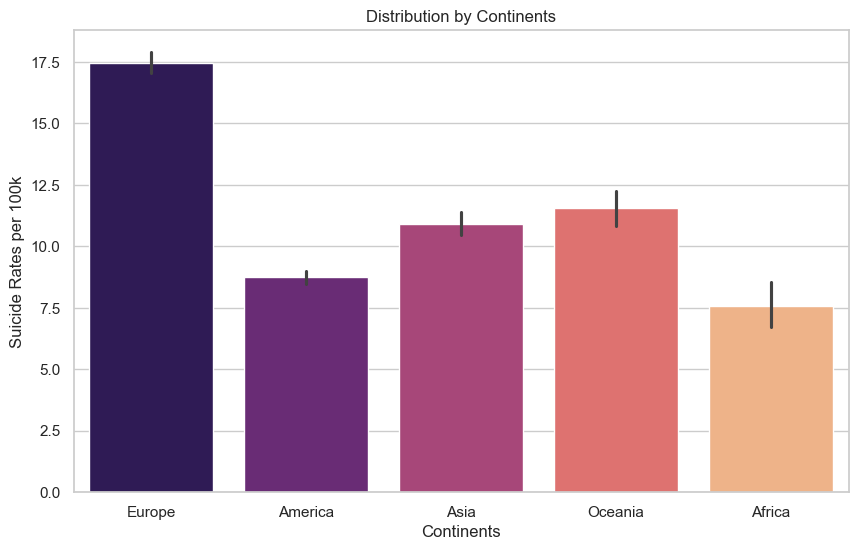

In [59]:
# suicide rates distribution by continents
plt.figure(figsize = (10,6))
sns.barplot(final_df, x = "continent", y = "suicides_per_100k", palette = "magma", hue = "continent", order = )
plt.title("Distribution by Continents")
plt.xlabel("Continents")
plt.ylabel("Suicide Rates per 100k")
plt.show()

#### Insight
European people are clearly more suicidal than the others.

### Average Rates by Country

In [61]:
# average rates by country and global average
country_avg = final_df.groupby("country")["suicides_per_100k"].mean().sort_values(ascending=False)
global_mean = final_df["suicides_per_100k"].mean()

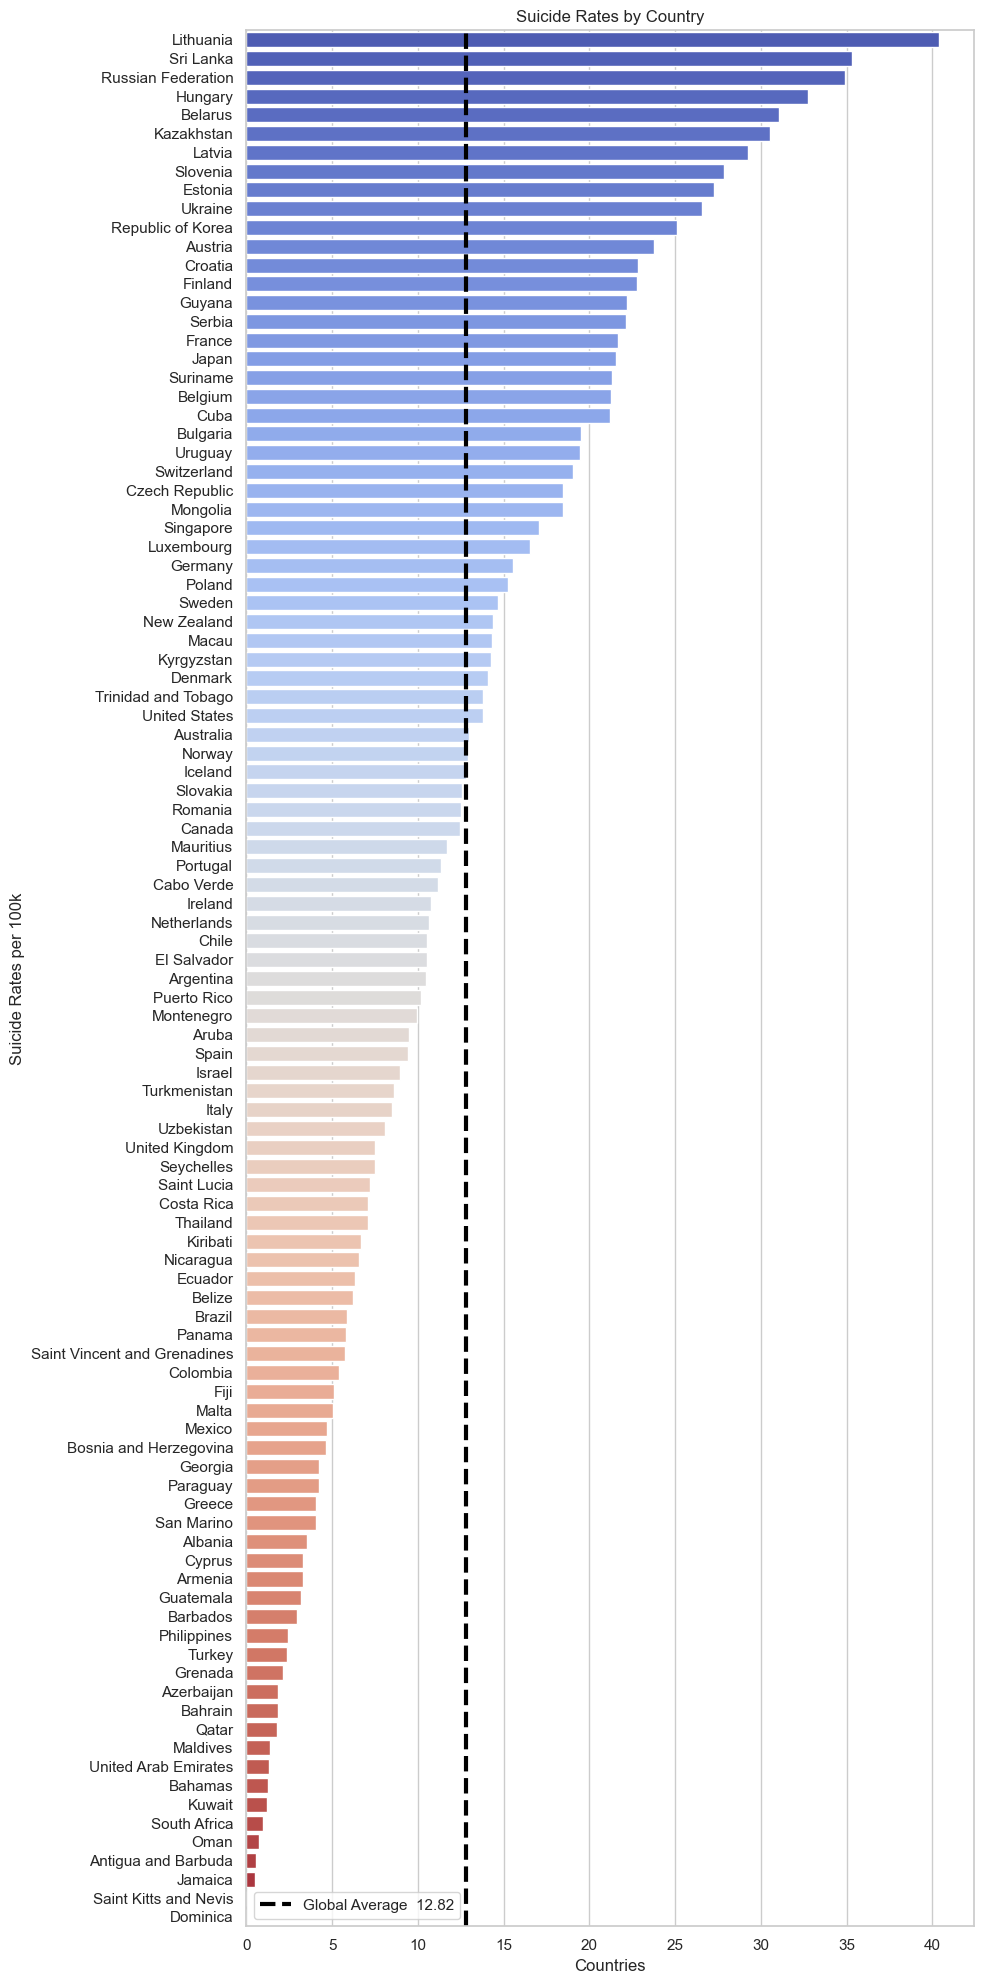

In [64]:
# visualization
plt.figure(figsize = (10,20))
sns.barplot(y = country_avg.index, x = country_avg.values,hue = country_avg.index, palette = "coolwarm")
plt.axvline(x = global_mean, color = "black", linestyle = "--", linewidth = 3, label = f"Global Average {global_mean: .2f}")
plt.title("Suicide Rates by Country")
plt.xlabel("Countries")
plt.ylabel("Suicide Rates per 100k")
plt.legend(loc )
plt.tight_layout()
plt.show()